In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils_cm_hypersphere import *
import plotly.graph_objects as go
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif', 
    'font.serif': ['cm'],
    'text.usetex': True,
    'figure.figsize' : (6.4, 4.0),
})

np.random.seed(1)


# Heatmap of cosine measure of the projected PSS of type 1 for the sphere of dimension 2

In [2]:

# Sanity test on the cosine measure algorithm ##################################################################
n = 7

a,b,c = generate_PSS(n, psstype=1), generate_PSS(n, psstype=2),generate_PSS(n, psstype=3)

print("1:",1/np.sqrt(n),compute_cm_HJB(a))    
print("2:", 1/np.sqrt(n**2+2*(n-1)*np.sqrt(n)), compute_cm_HJB(b))
print("3:", 1/n, compute_cm_HJB(c))

1: 0.3779644730092272 0.3779644730092272
2: 0.11128365503900636 0.1112836550390064
3: 0.14285714285714285 0.14285714285714282


In [6]:
# Computation of the heatmap on the sphere 
V_theta, V_phi, CM, X, pss, CM_intr = CM_heatmap_spheredim2(psstype = 1,n_samples = 10000, return_intrinsic_cm = True, tol_HJB=1e-14)

# for displaying of labels of PSS
pss_spread = 1.15*pss 
pss_labels = ["e1","e2","e3","-e1","-e2","-e3"]


zmin = min(CM.min(), CM_intr.min())
zmax = max(CM.max(), CM_intr.max())

In [7]:
# Plotting the heatmap with plotly ##################################################################
surface = go.Surface(x= X[:,:,0], y=X[:,:,1], z = X[:,:,2],
                     name = "cm",
                     colorscale = "Viridis",
                     colorbar=dict(
                        title="cm",
                        titleside="top",
                        titlefont=dict(size=25, family="serif"),
                        tickfont=dict(size=20, family="serif"),
                        x=0.9,      # horizontal position of colorbar (0:left, 1:right)
                        y=0.5,       # vertical center position (0:bottom, 1:top)
                        len=0.8,     # length of the colorbar (fraction of plot height)
                        thickness=20, # width in pixels
                        outlinecolor="black",  # optional border color
                    ),
                    surfacecolor= CM,opacity = 1)


pss_scatter = go.Scatter3d(x= pss[0], y=pss[1], z = pss[2], mode = "markers+text",
    marker=dict(
        size=5,
        color='red'),
        showlegend=False
)

pss_labels_scatter = go.Scatter3d(
    x=pss_spread[0],
    y=pss_spread[1],
    z=pss_spread[2],
    mode='text',
    text=pss_labels,
    textfont=dict(color="firebrick", size=25), 
    textposition="middle center",
    showlegend=False
)



fig = go.Figure()
fig.add_trace(pss_labels_scatter)
fig.add_trace(pss_scatter)
fig.add_trace(surface)




# Add title
fig.update_layout(
    title="titre",
    showlegend=True,
    #template="plotly_light",  # Apply a dark theme for all subplots
    title_x=0.5,  # center the title
    height=600,   # height of the figure
    width=650     # width of the figure
)


fig.update_layout(
    scene=dict(
        xaxis=dict(
            visible=False,    # hides everything related to the x-axis
            showbackground=False,
            showgrid=False,
            zeroline=False,
            showticklabels = True,
            ticks = "outside",
            title = "x"
        ),
        yaxis=dict(
            visible=False,
            showbackground=False,
            showgrid=False,
            zeroline=False,
        ),
        zaxis=dict(
            visible=False,
            showbackground=False,
            showgrid=False,
            zeroline=True,
        ),
        bgcolor="rgba(0,0,0,0)"  # transparent scene background
    ),
    paper_bgcolor="rgba(0,0,0,0)",  # transparent overall background
    plot_bgcolor="rgba(0,0,0,0)",
)


fig.update_layout(
    scene=dict(
        xaxis=dict(title="x"),
        yaxis=dict(title="y"),
        zaxis=dict(title="z"),
    ),
    margin=dict(l=0, r=0, t=0, b=0),  # small margins
)




camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=0.72, y=0.72, z=0.72)
)

fig.update_layout(scene_camera=camera)
fig.show()

fig.write_image("cosinemeasure_plots/"+"cm_pssproj1_heatmap.pdf", scale=1, width=800, height=700, engine="kaleido")


camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=1.247, y=0, z=0)
)
fig.update_layout(scene_camera=camera)
fig.show()
fig.write_image("cosinemeasure_plots/"+"cm_pssproj1_heatmap_view2.pdf", scale=1, width=800, height=700, engine="kaleido")

################ Entering dimension n =  3


  0%|          | 0/103 [00:00<?, ?it/s]

100%|██████████| 103/103 [00:00<00:00, 392.70it/s]


################ Entering dimension n =  4


100%|██████████| 103/103 [00:00<00:00, 167.35it/s]


...

100%|██████████| 103/103 [00:03<00:00, 26.67it/s]


################ Entering dimension n =  7


100%|██████████| 103/103 [00:09<00:00, 10.56it/s]


################ Entering dimension n =  8


100%|██████████| 103/103 [00:27<00:00,  3.79it/s]


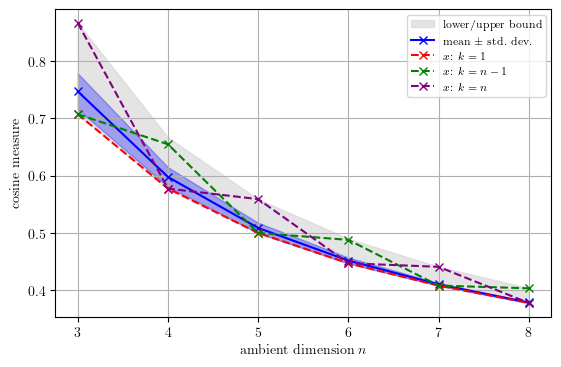

In [8]:
# Plot of the projected cosine measure of PSS 1 at various points, for various ambient dimensions ##################################################################
mindim, maxdim = 3,8

adims = np.arange(mindim,maxdim+1)
n_samples = 100
for psstype in [1]: #,2,3
    CMS_mean,CMS_sd, CMS_min, CMS_max, CMS_part_points, CMS_intr, part_points_labels,part_points_colors = compute_cm_with_dims(adims,psstype =psstype,n_samples=n_samples)


    plt.figure()
    default_width, default_height = plt.rcParams["figure.figsize"]
    titlefonts = 1789
    subtitle_fonts = 10
    label_fonts = 8

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True)) # display only integers on xaxis

    if psstype == 1:        
        ub = upper_bound_projcm(adims,psstype = 1,attempt_tight=False)
        lb = lower_bound_projcm(adims,psstype = 1)

        plt.fill_between(adims, lb, ub, color='lightgrey', alpha=0.6,label = "lower/upper bound")

    plt.plot(adims,CMS_mean,color = "blue", marker = "x", linestyle = "-", label = "mean $\\pm$ std. dev.")

    plt.fill_between(adims, CMS_mean-CMS_sd, CMS_mean+CMS_sd, color='blue', alpha=0.3)
    for k,_ in enumerate(CMS_part_points):
        plt.plot(adims, CMS_part_points[k],marker = "x", linestyle = "--",label = part_points_labels[k], color = part_points_colors[k])

    plt.xlabel("ambient dimension $n$",fontsize = subtitle_fonts)
    plt.ylabel("cosine measure", fontsize = subtitle_fonts)
    plt.grid(True)

    plt.legend(fontsize = label_fonts)
    plt.savefig("cosinemeasure_plots/"+"plotprojected_cm_psstype="+str(psstype)+"dimrange"+str(mindim)+"-"+str(maxdim)+".pdf",bbox_inches='tight', dpi=300)


# Computational time PSSs

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from problems import ProblemLinearSubspace, ProblemEigh
import os
import pickle
import pandas as pd

os.getcwd()

import numpy as np

import time
import time
np.random.seed(42)
import pymanopt as po


In [5]:
def time_compute(problemtype,mdims,adim, pss_instances = np.arange(1,11), psstypes = [1,2,3], projections = [0,1], rotations = [0,1], pb_instances = np.arange(1,10), printing = False,seed = 42
):
    """vn: rpz taille espace ambiant pour linear subspace et eigh, nombre de rotations pour synchrot
    vd : rpz dimension espace pour linear subspace et eigh, taille des matrices pour synchrot"""
    time_dic = []
    # for mdim, codim in itertools.product(mdims,codims): si je veux libérer codim de mdim
    for mdim in mdims:
        codim = adim - mdim
        print(f"Running for mdim={mdim}, codim={codim}") if printing else None
        adim = mdim + codim
        if problemtype == "eigh":
            problem = ProblemEigh(adim = adim,mdim = mdim)
        elif problemtype == "linearsubspace":
            B = po.manifolds.Stiefel(adim,mdim).random_point()
            problem = ProblemLinearSubspace(B)
        for pb_instance in pb_instances:
            np.random.seed(seed)
            x = problem.manifold.random_point()
            for rotation, projection, psstype, pss_instance in itertools.product(rotations, projections, psstypes, pss_instances):
                # print(f"Rotation: {rotation}, Projection: {projection}, PSS type: {psstype},pss instance: {pss_instance}, d: {mdim}, pb instance: {pb_instance}")
                s = time.process_time()
                problem.build_pss(x,projection=projection, rotation=rotation, psstype=psstype)
                e = time.process_time()
                time_dic.append({
                    "problemtype": problemtype,
                    "mdim": mdim,
                    "codim": codim,
                    "pb_instance": pb_instance,
                    "rotation": rotation,
                    "projection": projection,
                    "psstype": psstype,
                    "pss_instance": pss_instance,
                    "time": e-s
                })
    return time_dic



In [ ]:
# ! pip install tkinter

from tkinter import font

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["cm"],
        "text.usetex": True,
        # 'font.size' : 10,
        # "axes.labelsize": 10,
        # "legend.fontsize": 8,
        # "xtick.labelsize": 8,
        # "ytick.labelsize": 8,
        "figure.figsize": (6.4, 4.0),
        # "pgf.texsystem": "pdflatex",
    }
)

def plot_time_results(a, rot=0, adim=40):
    titlefonts = 28

    df = pd.DataFrame(a)

    # Average over all mdims for each combination of psstype, rotation, projection
    results = (
        df.groupby(["psstype", "rotation", "projection"])["time"]
        .agg(avgtime="mean", stdtime="std")
        .reset_index()
        .to_dict(orient="records")
    )

    keys = ["psstype", "rotation", "projection"]
    combos = df[(df["rotation"] == rot)][keys].drop_duplicates().to_dict(orient="records")
    types = sorted(df["psstype"].unique())
    linestyles = {0: "-", 1: ":"}

    fig, ax = plt.subplots()


    cmapproj = mpl.colormaps["Set1"].colors[1:4]
    cmapnoproj = mpl.colormaps["Set1"].colors[1:4]
    cmap = [cmapnoproj, cmapproj]
    linestyles = ["-", "--"]
    titlefonts = 28



    for combo in combos:
        mask = pd.Series([True] * len(df))
        for k, v in combo.items():
            mask &= df[k] == v
        mask &= (df["codim"] + df["mdim"]) == adim
        sub = df[mask].groupby("mdim")["time"].agg(avgtime="mean", stdtime="std").reset_index()
        ax.plot(
        sub["mdim"], sub["avgtime"],
        color=cmap[combo["projection"]][combo["psstype"] - 1],
        marker = ".",
        linestyle=linestyles[combo["projection"]],
        label=f"PSS{combo['psstype']} {['no proj.','proj.'][combo['projection']]}",
        )

        ax.fill_between(
            sub["mdim"],
            sub["avgtime"] - sub["stdtime"],
            sub["avgtime"] + sub["stdtime"],
            color=cmap[combo["projection"]][combo["psstype"] - 1], alpha=0.15
        )

    ax.set_yscale("log")

    from matplotlib.lines import Line2D
    ax.legend()
    ax.set_xlabel("manifold dimension $m$")
    ax.set_ylabel("CPU times (s)")
    # ax.set_title("Build PSS time vs mdim (rotation=0)")
    plt.tight_layout()
    plt.grid(True)
    plt.show()

    return results 


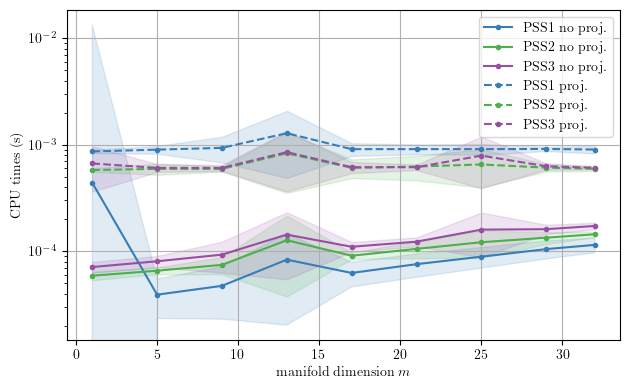

In [7]:
adim = 32
mdims = np.arange(1,adim,4)
mdims = np.append(mdims, adim)
seed=42
a = time_compute("linearsubspace", mdims=mdims, adim = adim, pss_instances = np.arange(0,100), pb_instances = np.arange(0,10), psstypes = [1,2,3], projections = [0,1], rotations = [0,1],printing = False, seed = seed)
pl = plot_time_results(a,rot = 1,adim = adim)

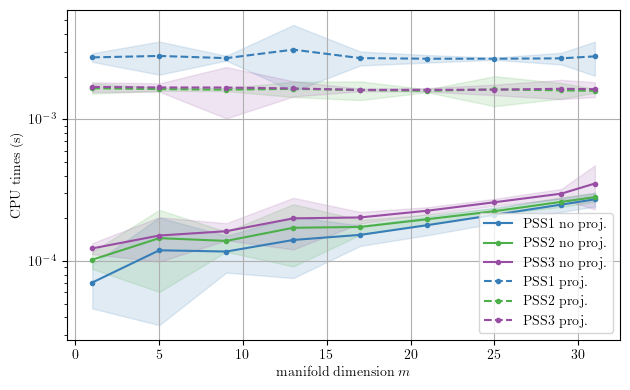

In [8]:
adim = 32
mdims = np.arange(1,adim,4)
mdims = np.append(mdims, adim-1)
a = time_compute("eigh", mdims=mdims, adim = adim, pss_instances = np.arange(0,100), pb_instances = np.arange(0,10), psstypes = [1,2,3], projections = [0,1], rotations = [0,1],printing = False)

pl = plot_time_results(a,rot = 1,adim = adim)